In [1]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from main.classes.neural_networks.training.train_arima import train_and_evaluate_arima, load_series

ModuleNotFoundError: No module named 'statsmodels'

In [64]:
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
os.makedirs(model_dir, exist_ok=True)

df = load_data(csv_path)

target = 'ITUB4'

In [65]:
try:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, target, order, model_dir, version, split_date,rolling,step_size)
    
    print(f"\nMétricas do modelo ARIMA para {target}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
except Exception as e:
    print(f"Erro durante o treinamento: {e}")


2025-06-15 19:59:12,647 - INFO - Carregando dados para ITUB4
2025-06-15 19:59:12,693 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-15 20:02:11,333 - INFO - 
Métricas no conjunto de teste:
2025-06-15 20:02:11,333 - INFO - MSE: 0.2386
2025-06-15 20:02:11,334 - INFO - RMSE: 0.4884
2025-06-15 20:02:11,334 - INFO - MAE: 0.3503
2025-06-15 20:02:11,335 - INFO - R2: 0.9806
2025-06-15 20:02:11,373 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima



Métricas do modelo ARIMA para ITUB4:
MSE: 0.2386
RMSE: 0.4884
MAE: 0.3503
R2: 0.9806


In [66]:
# Carregar os valores reais e previstos
test_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy"))
predicted_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy"))

# Obter as datas corretas
test_series = df[target].dropna()
test_dates = test_series.index[-len(test_values):]

In [67]:
# Recuperar a série completa para alinhar o y_true
full_series = df[target].dropna()
y_true = full_series[-len(predictions):]

# Caminhos dos arquivos
y_true_path = os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy")
y_pred_path = os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy")

# Salvar os arquivos .npy
np.save(y_true_path, y_true)
np.save(y_pred_path, predictions)

print(f"Valores salvos:\n- {y_true_path}\n- {y_pred_path}")

Valores salvos:
- ../../saved_models/arima\ITUB4_arima_rolling_y_true_v1.0.npy
- ../../saved_models/arima\ITUB4_arima_rolling_y_pred_v1.0.npy


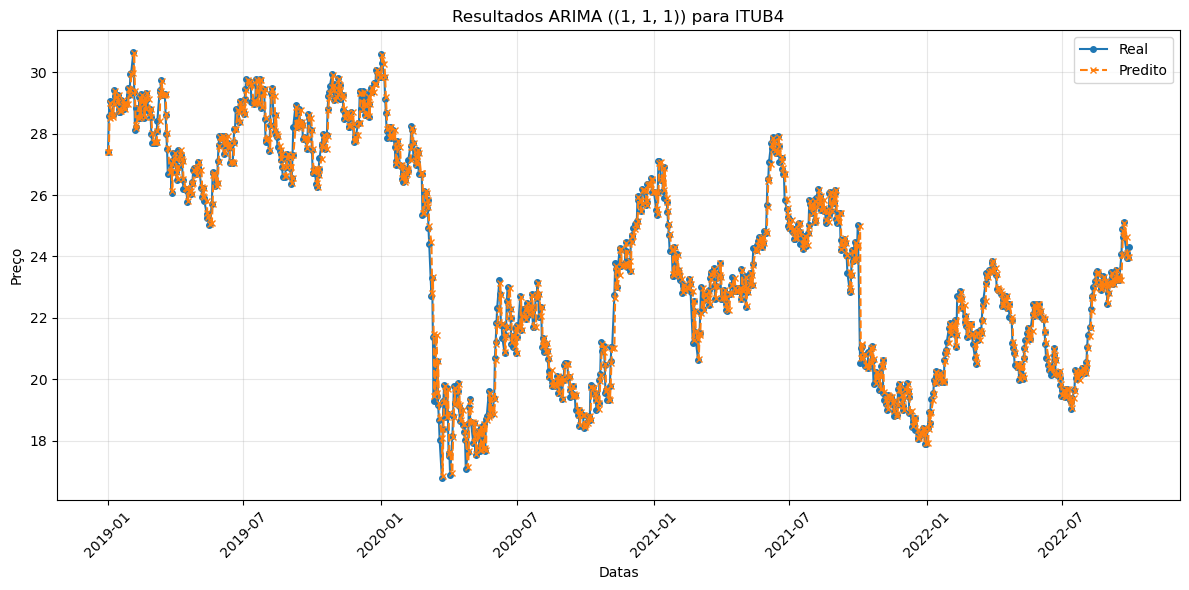

In [68]:
# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(test_dates, test_values, label='Real', marker='o', markersize=4)
plt.plot(test_dates, predicted_values, label='Predito', linestyle='--', marker='x', markersize=4)

plt.title(f"Resultados ARIMA ({order}) para {target}")
plt.xlabel('Datas')
plt.ylabel('Preço')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
import matplotlib.pyplot as plt

# Configurações básicas
acoes =['ITUB4', 'BBAS3', 'CYRE3', 'TEND3' ,'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
# Dicionário para armazenar os resultados
resultados_arima = {}
dates_map = {}

# Executa para cada ação
for acao in acoes:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, acao, order, model_dir, version, split_date, rolling,step_size)
    y_test = np.load(f"{model_dir}/{acao}_arima_rolling_y_true_v{version}.npy")
    resultados_arima[acao] = (y_test, predictions)

    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df = df.set_index('Date')
    df = df[df.index >= "2019-01-07"]
    dates_map[acao] = df.index[:len(y_test)]
        # Salva y_true e y_pred como .npy
        # Recupera valores reais do teste (mesmo número de pontos das previsões)
    serie = df[acao].dropna()
    y_true = serie[-len(predictions):]    
    np.save(f"{model_dir}/{acao}_arima_rolling_y_true_v{version}.npy", y_true)
    np.save(f"{model_dir}/{acao}_arima_rolling_y_pred_v{version}.npy", predictions)
# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=False)

for i, acao in enumerate(acoes):
    y_test, predictions = resultados_arima[acao]
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    # Obtem a série alvo completa (com datas)
    test_series = df[acao].dropna()
    test_dates = test_series.index[-len(y_test):]

    dates_map[acao] = test_dates
    axes[i].plot(test_dates, y_test, label=f'Real {acao}')
    axes[i].plot(test_dates, predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()


2025-06-15 20:02:11,636 - INFO - Carregando dados para ITUB4
2025-06-15 20:02:11,677 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-15 20:05:06,977 - INFO - 
Métricas no conjunto de teste:
2025-06-15 20:05:06,978 - INFO - MSE: 0.2386
2025-06-15 20:05:06,979 - INFO - RMSE: 0.4884
2025-06-15 20:05:06,979 - INFO - MAE: 0.3503
2025-06-15 20:05:06,980 - INFO - R2: 0.9806
2025-06-15 20:05:07,023 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima
2

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Emanuel\AppData\Local\Temp\ipykernel_3876\2524407856.py", line 18, in <module>
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, acao, order, model_dir, version, split_date, rolling,step_size)
  File "c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\training\train_arima.py", line 68, in train_and_evaluate_arima
  File "c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py", line 26, in update
    self.model_fit = self.model_fit.append(new_value, refit=False)
  File "c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\arima\model.py", line 517, in append
    out = super().append(endog, exog=exog, refit=refit,
  F

Parte da Regressão Linear para Gerar A comparação entre os 3.

In [70]:
import os
import sys
sys.path.append(os.path.abspath("../../"))

# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
from classes.neural_networks.training.train_linear_regression import train_and_evaluate, load_data
# Define os parâmetros
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
window = 3
model_dir = "../../saved_models/regressao"
version = "v1.0"
# Carrega os dados para obter as datas
df = load_data(csv_path)
df.sort_values("Date", inplace=True)
dates = df['Date'].values
target = "ITUB4"

2025-06-15 20:07:46,397 - INFO - Carregando dados do CSV para a ação ITUB4
2025-06-15 20:07:46,414 - INFO - Normalizando dados
2025-06-15 20:07:46,417 - INFO - Treinando modelo usando a equação normal
2025-06-15 20:07:46,418 - INFO - Desnormalizando previsões
2025-06-15 20:07:46,419 - INFO - Avaliando modelo
2025-06-15 20:07:46,422 - INFO - 
Métricas de Treino:
2025-06-15 20:07:46,423 - INFO - MSE: 0.0539
2025-06-15 20:07:46,424 - INFO - RMSE: 0.2322
2025-06-15 20:07:46,424 - INFO - MAE: 0.1657
2025-06-15 20:07:46,425 - INFO - R2: 0.9960
2025-06-15 20:07:46,425 - INFO - 
Métricas de Validação:
2025-06-15 20:07:46,426 - INFO - MSE: 0.2061
2025-06-15 20:07:46,426 - INFO - RMSE: 0.4540
2025-06-15 20:07:46,427 - INFO - MAE: 0.3501
2025-06-15 20:07:46,427 - INFO - R2: 0.9564
2025-06-15 20:07:46,428 - INFO - 
Métricas de Teste:
2025-06-15 20:07:46,428 - INFO - MSE: 0.2499
2025-06-15 20:07:46,429 - INFO - RMSE: 0.4999
2025-06-15 20:07:46,430 - INFO - MAE: 0.3664
2025-06-15 20:07:46,430 - INFO

Parâmetros do modelo: [4.38040627e-04 9.88015060e-01 2.99275995e-03 8.74488947e-03]
Métricas de Treino: {'MSE': 0.05393999672719481, 'RMSE': 0.2322498584008068, 'MAE': 0.16566143115191387, 'R2': 0.9959842642392567}
Métricas de Validação: {'MSE': 0.20614253857874376, 'RMSE': 0.4540292265688892, 'MAE': 0.35013730610511673, 'R2': 0.9563970908989935}
Métricas de Teste: {'MSE': 0.2498567452803604, 'RMSE': 0.4998567247525639, 'MAE': 0.3663662416365265, 'R2': 0.9794705355745817}


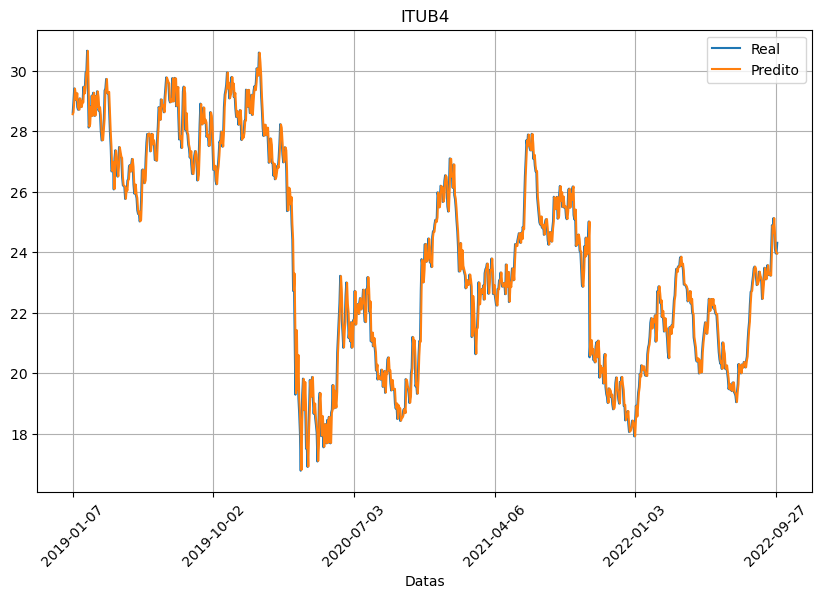

In [71]:
# Chama a função para treinar e avaliar o modelo
model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, target, window,model_dir, version)

# Exibe os parâmetros do modelo e as métricas de treino, validação e teste
print("Parâmetros do modelo:", theta)
print("Métricas de Treino:", train_metrics)
print("Métricas de Validação:", val_metrics)
print("Métricas de Teste:", test_metrics)

# Visualiza os resultados
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Real')
plt.plot(test_predictions, label='Predito',)

# Adiciona as datas no eixo x
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
plt.xticks(ticks=range(0, num_dates, step), labels=dates[-num_dates::step], rotation=45)

plt.title(target)
plt.xlabel('Datas')
plt.grid(True)
plt.legend()
plt.show()

2025-06-15 20:07:49,267 - INFO - Carregando dados do CSV para a ação CMIG4
2025-06-15 20:07:49,284 - INFO - Normalizando dados
2025-06-15 20:07:49,287 - INFO - Treinando modelo usando a equação normal
2025-06-15 20:07:49,288 - INFO - Desnormalizando previsões
2025-06-15 20:07:49,289 - INFO - Avaliando modelo
2025-06-15 20:07:49,293 - INFO - 
Métricas de Treino:
2025-06-15 20:07:49,293 - INFO - MSE: 0.0034
2025-06-15 20:07:49,294 - INFO - RMSE: 0.0584
2025-06-15 20:07:49,294 - INFO - MAE: 0.0404
2025-06-15 20:07:49,295 - INFO - R2: 0.9902
2025-06-15 20:07:49,295 - INFO - 
Métricas de Validação:
2025-06-15 20:07:49,296 - INFO - MSE: 0.0041
2025-06-15 20:07:49,296 - INFO - RMSE: 0.0639
2025-06-15 20:07:49,297 - INFO - MAE: 0.0450
2025-06-15 20:07:49,297 - INFO - R2: 0.9848
2025-06-15 20:07:49,298 - INFO - 
Métricas de Teste:
2025-06-15 20:07:49,298 - INFO - MSE: 0.0093
2025-06-15 20:07:49,299 - INFO - RMSE: 0.0966
2025-06-15 20:07:49,299 - INFO - MAE: 0.0707
2025-06-15 20:07:49,300 - INFO

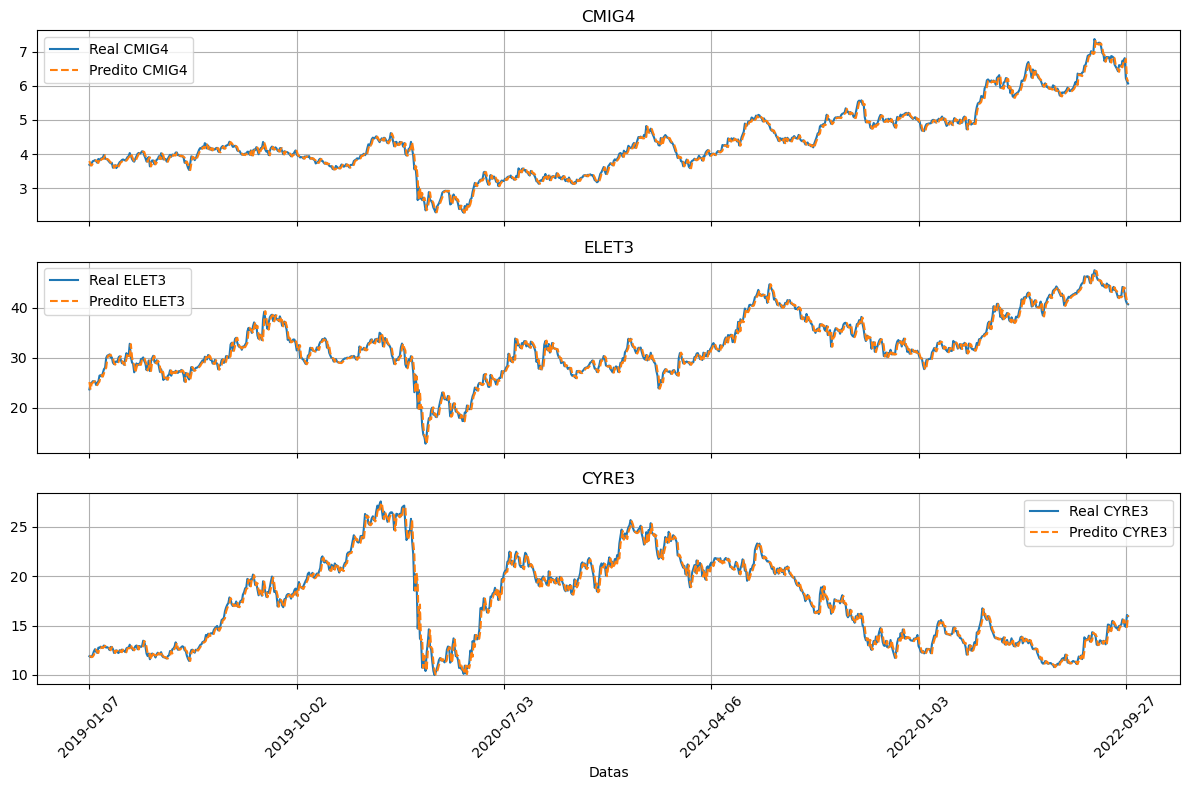

In [72]:
# Lista de ações a serem analisadas
acoes = ["CMIG4", "ELET3", "CYRE3",]

# Dicionário para armazenar os resultados
resultados = {}

# Treina e avalia o modelo para cada ação
for acao in acoes:
    model, theta, train_metrics, val_metrics, test_metrics, y_test, test_predictions = train_and_evaluate(csv_path, acao, window,model_dir, version)
    resultados[acao] = (y_test, test_predictions)

# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=True)

for i, acao in enumerate(acoes):
    y_test, test_predictions = resultados[acao]
    axes[i].plot(y_test, label=f'Real {acao}')
    axes[i].plot(test_predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

# Adiciona as datas no eixo x do último subplot
num_dates = len(y_test)
step = num_dates // 5  # Define o intervalo para 5 datas
axes[-1].set_xticks(range(0, num_dates, step))
axes[-1].set_xticklabels(dates[-num_dates::step], rotation=45)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()

2025-06-16 19:41:45,031 - INFO - Carregando dados do CSV para a ação ITUB4
2025-06-16 19:41:45,057 - INFO - Normalizando dados
2025-06-16 19:41:45,065 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:41:45,067 - INFO - Desnormalizando previsões
2025-06-16 19:41:45,069 - INFO - Avaliando modelo
2025-06-16 19:41:45,075 - INFO - 
Métricas de Treino:
2025-06-16 19:41:45,076 - INFO - MSE: 0.0539
2025-06-16 19:41:45,076 - INFO - RMSE: 0.2322
2025-06-16 19:41:45,077 - INFO - MAE: 0.1657
2025-06-16 19:41:45,078 - INFO - R2: 0.9960
2025-06-16 19:41:45,078 - INFO - 
Métricas de Validação:
2025-06-16 19:41:45,079 - INFO - MSE: 0.2061
2025-06-16 19:41:45,080 - INFO - RMSE: 0.4540
2025-06-16 19:41:45,081 - INFO - MAE: 0.3501
2025-06-16 19:41:45,081 - INFO - R2: 0.9564
2025-06-16 19:41:45,082 - INFO - 
Métricas de Teste:
2025-06-16 19:41:45,082 - INFO - MSE: 0.2499
2025-06-16 19:41:45,082 - INFO - RMSE: 0.4999
2025-06-16 19:41:45,083 - INFO - MAE: 0.3664
2025-06-16 19:41:45,083 - INFO


Processando: ITUB4


c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-16 19:44:41,674 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:44:41,675 - INFO - MSE: 0.2386
2025-06-16 19:44:41,676 - INFO - RMSE: 0.4884
2025-06-16 19:44:41,676 - INFO - MAE: 0.3503
2025-06-16 19:44:41,677 - INFO - R2: 0.9806
2025-06-16 19:44:41,728 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:44:41,735 - INFO - Carregando dados para ITUB4
2025-06-16 19:44:41,788 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 9


Métricas do modelo ARIMA para ITUB4:
MSE: 0.2386
RMSE: 0.4884
MAE: 0.3503
R2: 0.9806


2025-06-16 19:44:42,303 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:44:42,304 - INFO - MSE: 24.1392
2025-06-16 19:44:42,304 - INFO - RMSE: 4.9132
2025-06-16 19:44:42,305 - INFO - MAE: 4.0273
2025-06-16 19:44:42,305 - INFO - R2: -0.9676
2025-06-16 19:44:42,343 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


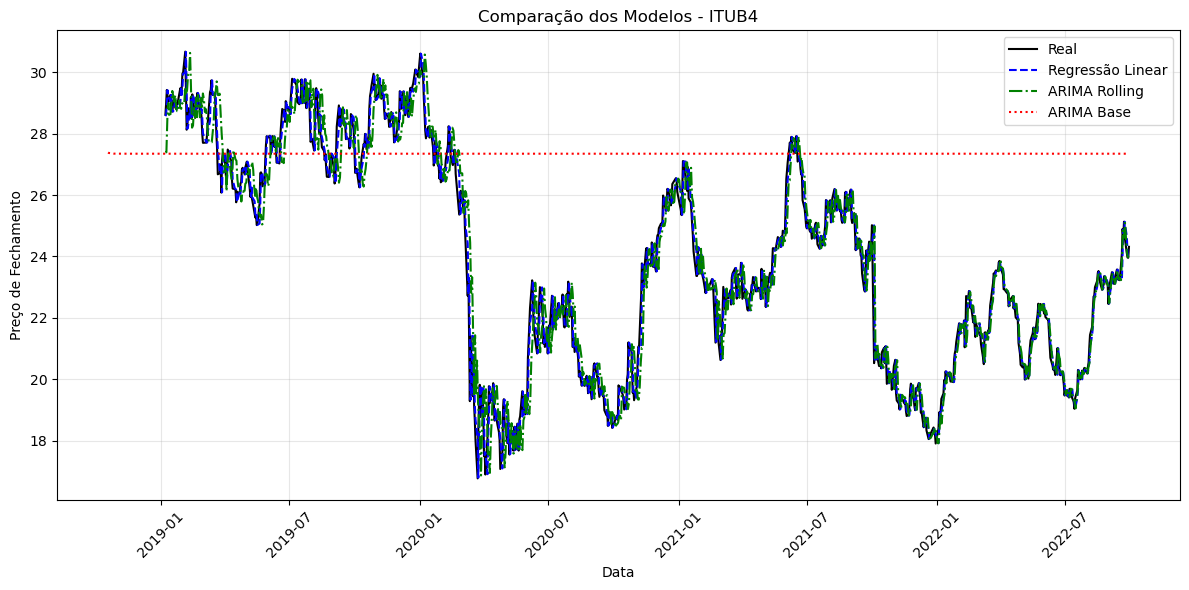

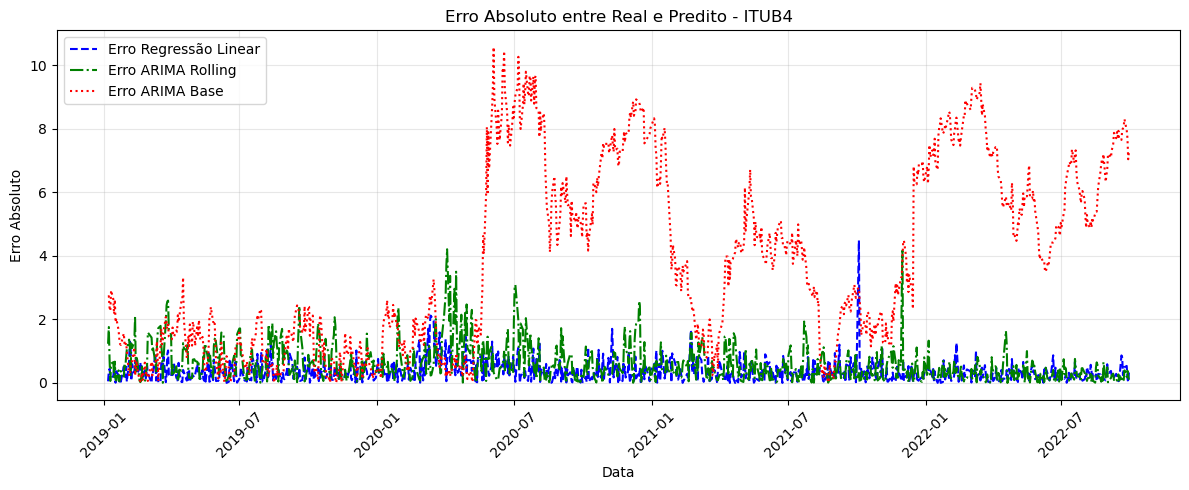

2025-06-16 19:44:42,818 - INFO - Carregando dados do CSV para a ação BBAS3
2025-06-16 19:44:42,834 - INFO - Normalizando dados
2025-06-16 19:44:42,837 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:44:42,838 - INFO - Desnormalizando previsões
2025-06-16 19:44:42,839 - INFO - Avaliando modelo
2025-06-16 19:44:42,844 - INFO - 
Métricas de Treino:
2025-06-16 19:44:42,844 - INFO - MSE: 0.0281
2025-06-16 19:44:42,845 - INFO - RMSE: 0.1676
2025-06-16 19:44:42,846 - INFO - MAE: 0.1158
2025-06-16 19:44:42,846 - INFO - R2: 0.9899
2025-06-16 19:44:42,847 - INFO - 
Métricas de Validação:
2025-06-16 19:44:42,847 - INFO - MSE: 0.0835
2025-06-16 19:44:42,848 - INFO - RMSE: 0.2890
2025-06-16 19:44:42,848 - INFO - MAE: 0.2225
2025-06-16 19:44:42,849 - INFO - R2: 0.9770
2025-06-16 19:44:42,849 - INFO - 
Métricas de Teste:
2025-06-16 19:44:42,850 - INFO - MSE: 0.1167
2025-06-16 19:44:42,851 - INFO - RMSE: 0.3416
2025-06-16 19:44:42,851 - INFO - MAE: 0.2373
2025-06-16 19:44:42,852 - INFO


Processando: BBAS3


2025-06-16 19:47:40,354 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:47:40,354 - INFO - MSE: 0.1114
2025-06-16 19:47:40,355 - INFO - RMSE: 0.3337
2025-06-16 19:47:40,355 - INFO - MAE: 0.2261
2025-06-16 19:47:40,356 - INFO - R2: 0.9834
2025-06-16 19:47:40,399 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:47:40,403 - INFO - Carregando dados para BBAS3
2025-06-16 19:47:40,444 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para BBAS3:
MSE: 0.1114
RMSE: 0.3337
MAE: 0.2261
R2: 0.9834


2025-06-16 19:47:40,725 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:47:40,725 - INFO - MSE: 8.3414
2025-06-16 19:47:40,726 - INFO - RMSE: 2.8882
2025-06-16 19:47:40,726 - INFO - MAE: 2.5566
2025-06-16 19:47:40,727 - INFO - R2: -0.2448
2025-06-16 19:47:40,763 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


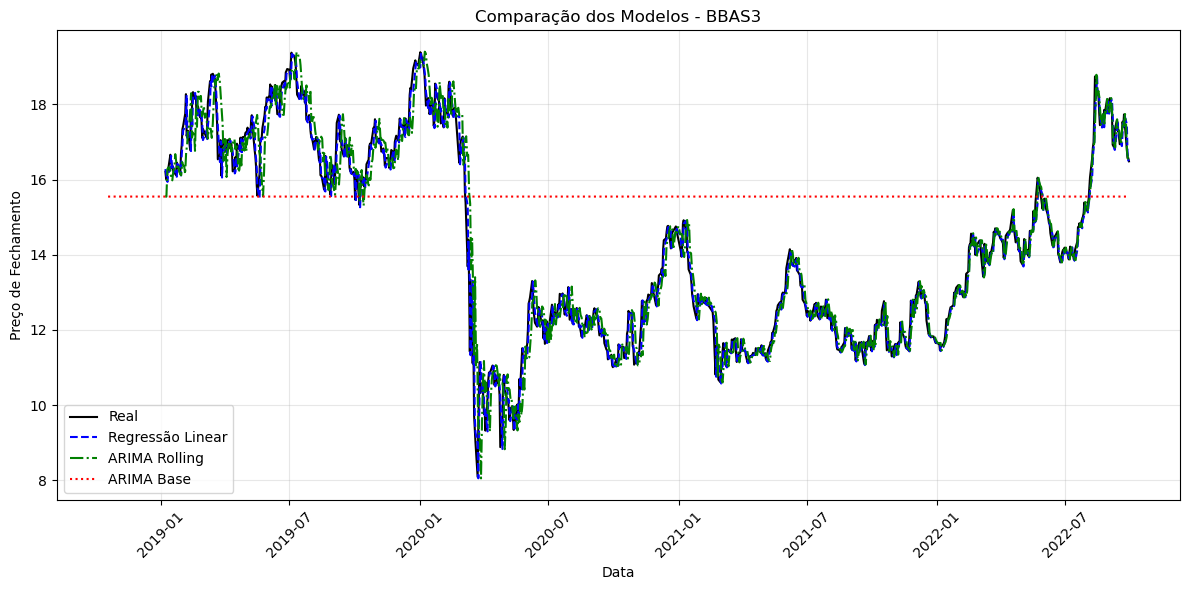

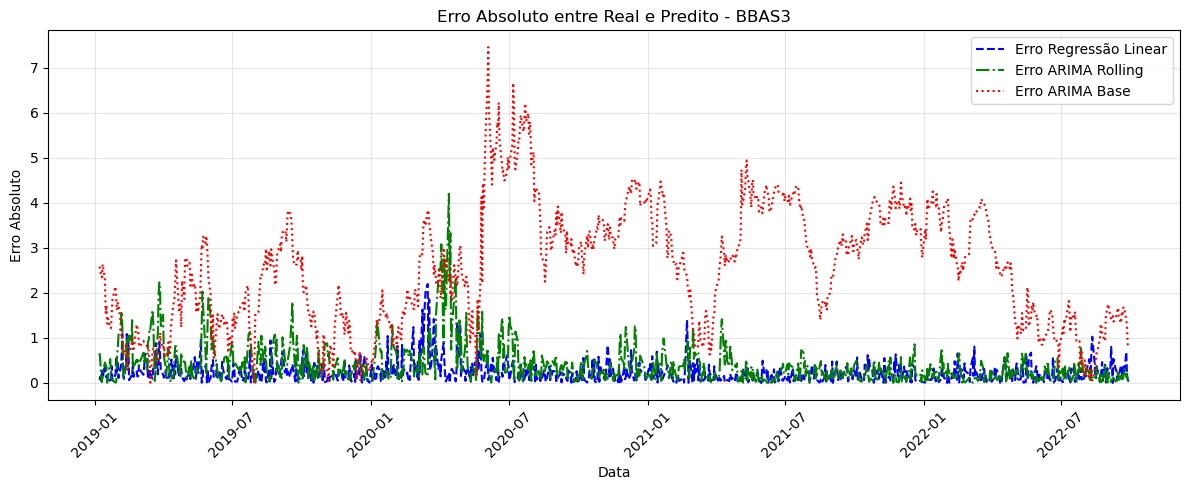

2025-06-16 19:47:41,198 - INFO - Carregando dados do CSV para a ação CYRE3
2025-06-16 19:47:41,215 - INFO - Normalizando dados
2025-06-16 19:47:41,217 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:47:41,219 - INFO - Desnormalizando previsões
2025-06-16 19:47:41,220 - INFO - Avaliando modelo
2025-06-16 19:47:41,224 - INFO - 
Métricas de Treino:
2025-06-16 19:47:41,225 - INFO - MSE: 0.0506
2025-06-16 19:47:41,225 - INFO - RMSE: 0.2249
2025-06-16 19:47:41,226 - INFO - MAE: 0.1641
2025-06-16 19:47:41,227 - INFO - R2: 0.9897
2025-06-16 19:47:41,227 - INFO - 
Métricas de Validação:
2025-06-16 19:47:41,228 - INFO - MSE: 0.0456
2025-06-16 19:47:41,228 - INFO - RMSE: 0.2135
2025-06-16 19:47:41,229 - INFO - MAE: 0.1608
2025-06-16 19:47:41,230 - INFO - R2: 0.9640
2025-06-16 19:47:41,230 - INFO - 
Métricas de Teste:
2025-06-16 19:47:41,231 - INFO - MSE: 0.3380
2025-06-16 19:47:41,231 - INFO - RMSE: 0.5813
2025-06-16 19:47:41,232 - INFO - MAE: 0.4042
2025-06-16 19:47:41,232 - INFO


Processando: CYRE3


c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Emanuel\miniconda3\envs\dev_ia\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
2025-06-16 19:50:38,531 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:50:38,531 - INFO - MSE: 0.3177
2025-06-16 19:50:38,532 - INFO - RMSE: 0.5637
2025-06-16 19:50:38,532 - INFO - MAE: 0.3842
2025-06-16 19:50:38,533 - INFO - R2: 0.9838
2025-06-16 19:50:38,576 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:50:38,579 - INFO - Carregando dados para CYRE3
2025-06-16 19:50:38,620 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 9


Métricas do modelo ARIMA para CYRE3:
MSE: 0.3177
RMSE: 0.5637
MAE: 0.3842
R2: 0.9838


2025-06-16 19:50:39,135 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:50:39,136 - INFO - MSE: 53.2639
2025-06-16 19:50:39,137 - INFO - RMSE: 7.2982
2025-06-16 19:50:39,137 - INFO - MAE: 5.8539
2025-06-16 19:50:39,138 - INFO - R2: -1.7188
2025-06-16 19:50:39,172 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


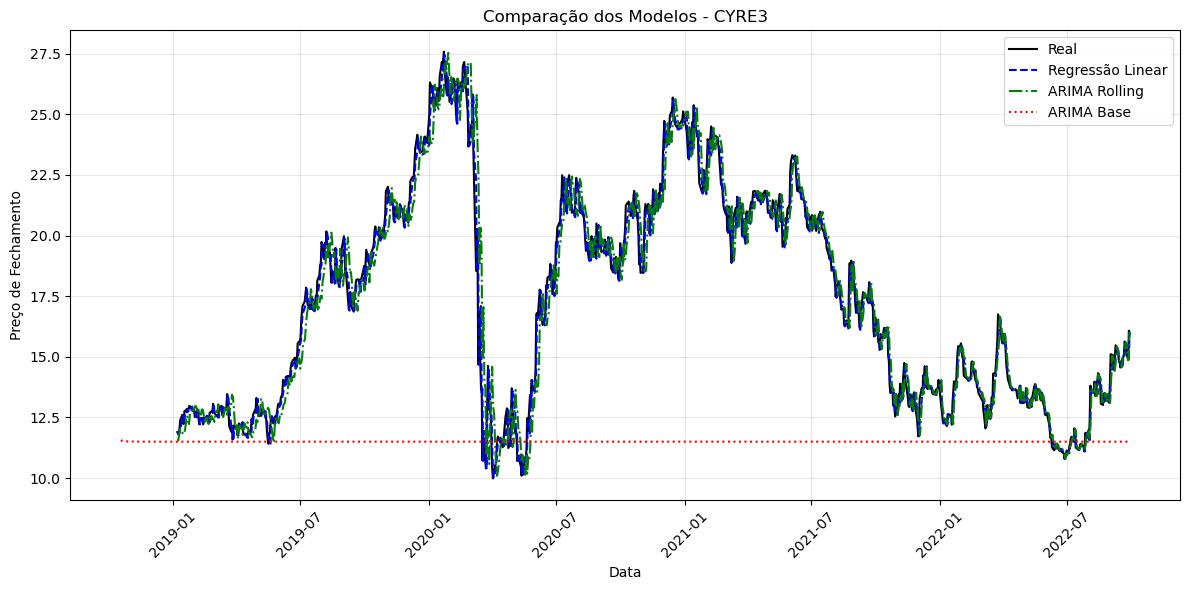

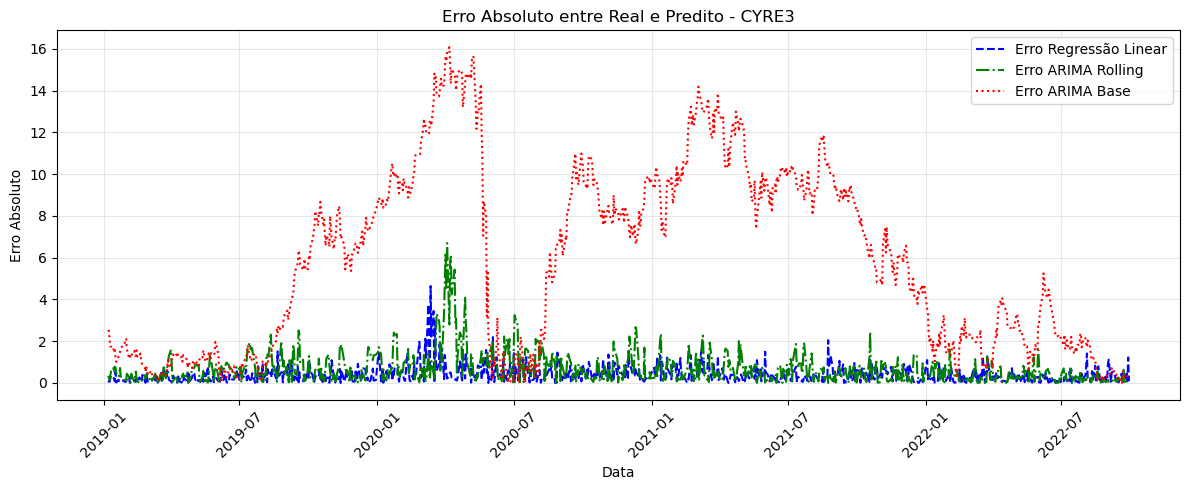

2025-06-16 19:50:39,599 - INFO - Carregando dados do CSV para a ação TEND3
2025-06-16 19:50:39,616 - INFO - Normalizando dados
2025-06-16 19:50:39,619 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:50:39,620 - INFO - Desnormalizando previsões
2025-06-16 19:50:39,621 - INFO - Avaliando modelo
2025-06-16 19:50:39,625 - INFO - 
Métricas de Treino:
2025-06-16 19:50:39,626 - INFO - MSE: 0.0038
2025-06-16 19:50:39,627 - INFO - RMSE: 0.0614
2025-06-16 19:50:39,627 - INFO - MAE: 0.0112
2025-06-16 19:50:39,628 - INFO - R2: 0.9937
2025-06-16 19:50:39,629 - INFO - 
Métricas de Validação:
2025-06-16 19:50:39,629 - INFO - MSE: 0.0579
2025-06-16 19:50:39,630 - INFO - RMSE: 0.2406
2025-06-16 19:50:39,631 - INFO - MAE: 0.1790
2025-06-16 19:50:39,631 - INFO - R2: 0.9641
2025-06-16 19:50:39,632 - INFO - 
Métricas de Teste:
2025-06-16 19:50:39,632 - INFO - MSE: 0.4892
2025-06-16 19:50:39,633 - INFO - RMSE: 0.6995
2025-06-16 19:50:39,633 - INFO - MAE: 0.4801
2025-06-16 19:50:39,634 - INFO


Processando: TEND3


2025-06-16 19:53:37,677 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:53:37,678 - INFO - MSE: 0.4434
2025-06-16 19:53:37,678 - INFO - RMSE: 0.6659
2025-06-16 19:53:37,679 - INFO - MAE: 0.4468
2025-06-16 19:53:37,679 - INFO - R2: 0.9932
2025-06-16 19:53:37,726 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:53:37,730 - INFO - Carregando dados para TEND3
2025-06-16 19:53:37,774 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para TEND3:
MSE: 0.4434
RMSE: 0.6659
MAE: 0.4468
R2: 0.9932


2025-06-16 19:53:38,070 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:53:38,071 - INFO - MSE: 97.0561
2025-06-16 19:53:38,072 - INFO - RMSE: 9.8517
2025-06-16 19:53:38,072 - INFO - MAE: 8.4692
2025-06-16 19:53:38,073 - INFO - R2: -0.4970
2025-06-16 19:53:38,114 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


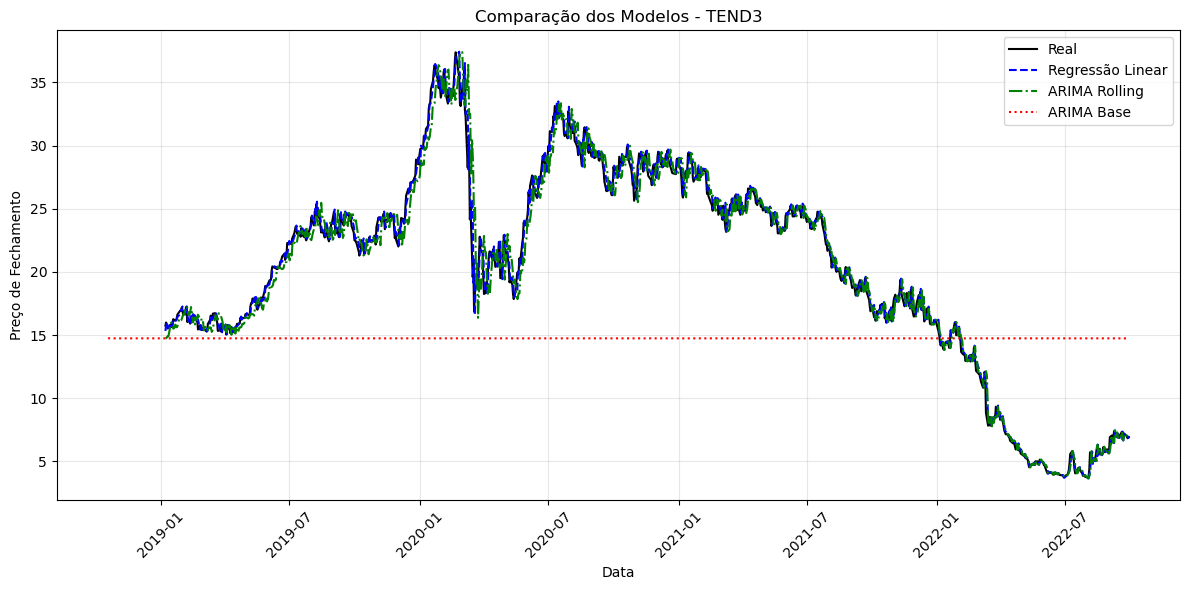

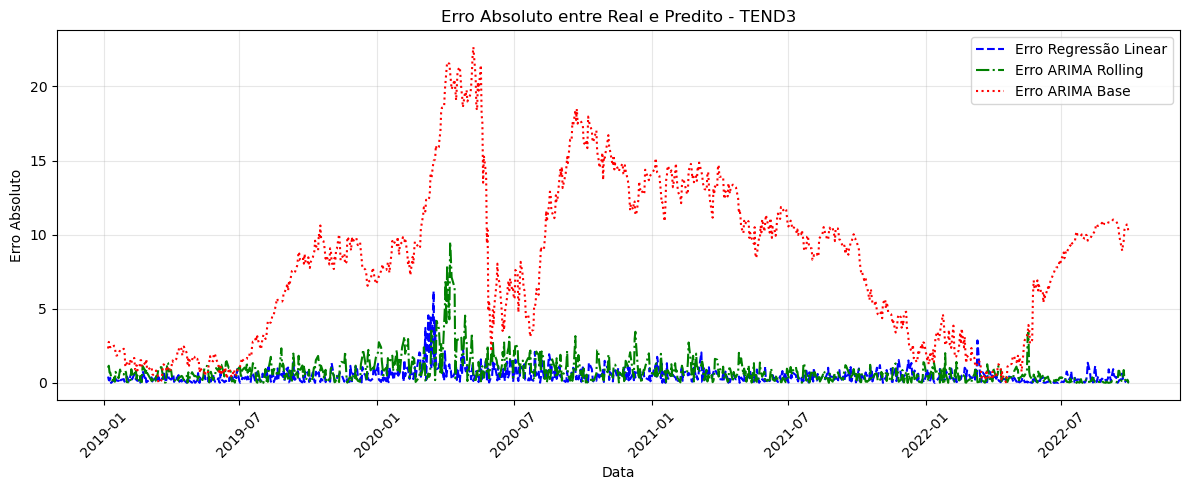

2025-06-16 19:53:38,536 - INFO - Carregando dados do CSV para a ação DIRR3
2025-06-16 19:53:38,552 - INFO - Normalizando dados
2025-06-16 19:53:38,555 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:53:38,556 - INFO - Desnormalizando previsões
2025-06-16 19:53:38,557 - INFO - Avaliando modelo
2025-06-16 19:53:38,561 - INFO - 
Métricas de Treino:
2025-06-16 19:53:38,562 - INFO - MSE: 0.0102
2025-06-16 19:53:38,562 - INFO - RMSE: 0.1008
2025-06-16 19:53:38,563 - INFO - MAE: 0.0733
2025-06-16 19:53:38,563 - INFO - R2: 0.9947
2025-06-16 19:53:38,564 - INFO - 
Métricas de Validação:
2025-06-16 19:53:38,564 - INFO - MSE: 0.0060
2025-06-16 19:53:38,565 - INFO - RMSE: 0.0772
2025-06-16 19:53:38,565 - INFO - MAE: 0.0597
2025-06-16 19:53:38,566 - INFO - R2: 0.9726
2025-06-16 19:53:38,566 - INFO - 
Métricas de Teste:
2025-06-16 19:53:38,568 - INFO - MSE: 0.0795
2025-06-16 19:53:38,569 - INFO - RMSE: 0.2820
2025-06-16 19:53:38,569 - INFO - MAE: 0.2098
2025-06-16 19:53:38,570 - INFO


Processando: DIRR3


2025-06-16 19:56:34,480 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:56:34,480 - INFO - MSE: 0.0755
2025-06-16 19:56:34,481 - INFO - RMSE: 0.2748
2025-06-16 19:56:34,481 - INFO - MAE: 0.1997
2025-06-16 19:56:34,482 - INFO - R2: 0.9766
2025-06-16 19:56:34,528 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:56:34,536 - INFO - Carregando dados para DIRR3
2025-06-16 19:56:34,589 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para DIRR3:
MSE: 0.0755
RMSE: 0.2748
MAE: 0.1997
R2: 0.9766


2025-06-16 19:56:34,968 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:56:34,969 - INFO - MSE: 20.4379
2025-06-16 19:56:34,969 - INFO - RMSE: 4.5208
2025-06-16 19:56:34,970 - INFO - MAE: 4.1489
2025-06-16 19:56:34,970 - INFO - R2: -5.3386
2025-06-16 19:56:35,007 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


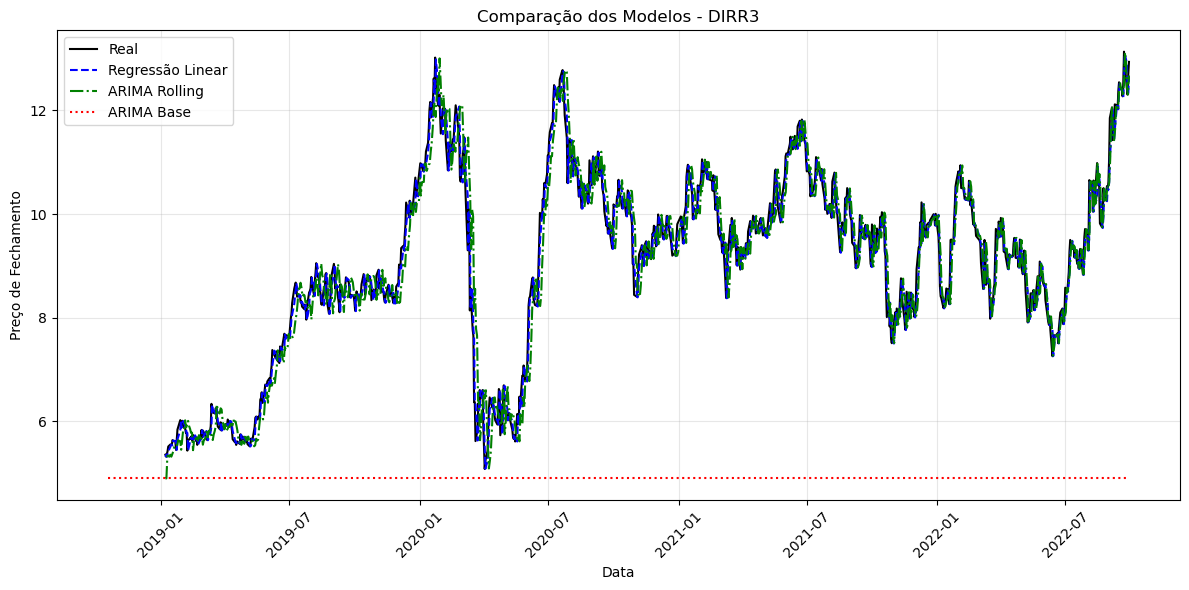

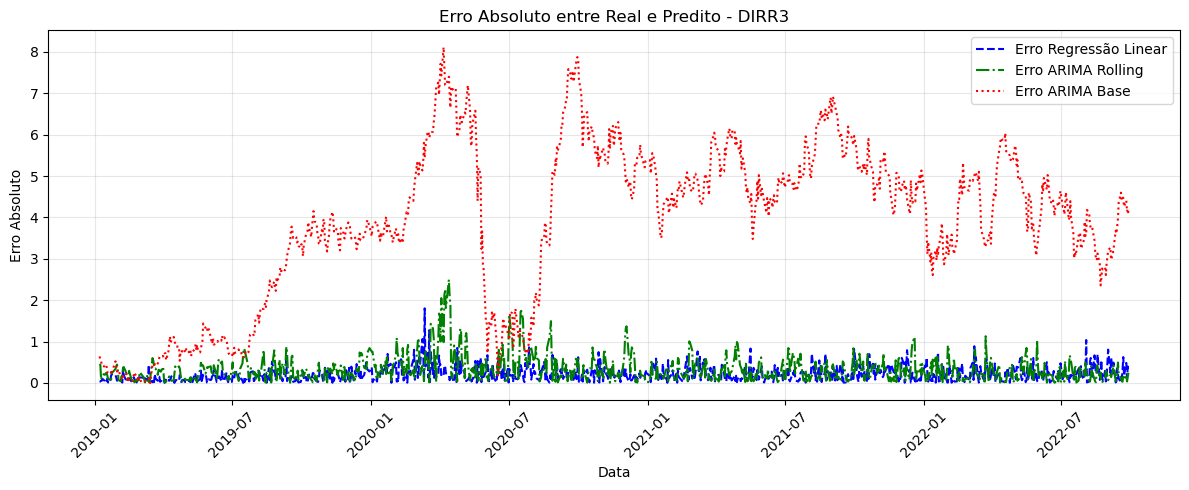

2025-06-16 19:56:35,430 - INFO - Carregando dados do CSV para a ação ELET3
2025-06-16 19:56:35,446 - INFO - Normalizando dados
2025-06-16 19:56:35,449 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:56:35,451 - INFO - Desnormalizando previsões
2025-06-16 19:56:35,452 - INFO - Avaliando modelo
2025-06-16 19:56:35,457 - INFO - 
Métricas de Treino:
2025-06-16 19:56:35,458 - INFO - MSE: 0.1000
2025-06-16 19:56:35,458 - INFO - RMSE: 0.3162
2025-06-16 19:56:35,459 - INFO - MAE: 0.1807
2025-06-16 19:56:35,459 - INFO - R2: 0.9958
2025-06-16 19:56:35,462 - INFO - 
Métricas de Validação:
2025-06-16 19:56:35,463 - INFO - MSE: 0.3826
2025-06-16 19:56:35,464 - INFO - RMSE: 0.6185
2025-06-16 19:56:35,465 - INFO - MAE: 0.4641
2025-06-16 19:56:35,465 - INFO - R2: 0.9596
2025-06-16 19:56:35,466 - INFO - 
Métricas de Teste:
2025-06-16 19:56:35,466 - INFO - MSE: 0.8560
2025-06-16 19:56:35,467 - INFO - RMSE: 0.9252
2025-06-16 19:56:35,467 - INFO - MAE: 0.6730
2025-06-16 19:56:35,468 - INFO


Processando: ELET3


2025-06-16 19:59:31,255 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:59:31,256 - INFO - MSE: 0.8350
2025-06-16 19:59:31,256 - INFO - RMSE: 0.9138
2025-06-16 19:59:31,257 - INFO - MAE: 0.6387
2025-06-16 19:59:31,258 - INFO - R2: 0.9773
2025-06-16 19:59:31,301 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 19:59:31,304 - INFO - Carregando dados para ELET3
2025-06-16 19:59:31,347 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para ELET3:
MSE: 0.8350
RMSE: 0.9138
MAE: 0.6387
R2: 0.9773


2025-06-16 19:59:31,591 - INFO - 
Métricas no conjunto de teste:
2025-06-16 19:59:31,592 - INFO - MSE: 193.4558
2025-06-16 19:59:31,592 - INFO - RMSE: 13.9088
2025-06-16 19:59:31,593 - INFO - MAE: 12.6314
2025-06-16 19:59:31,593 - INFO - R2: -4.2576
2025-06-16 19:59:31,629 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


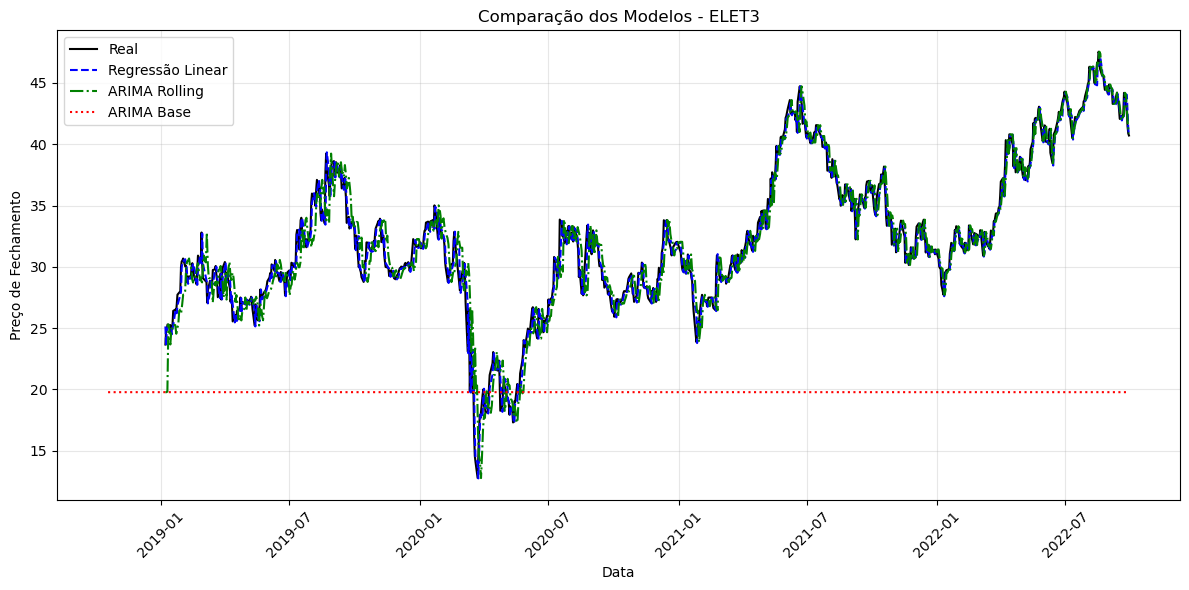

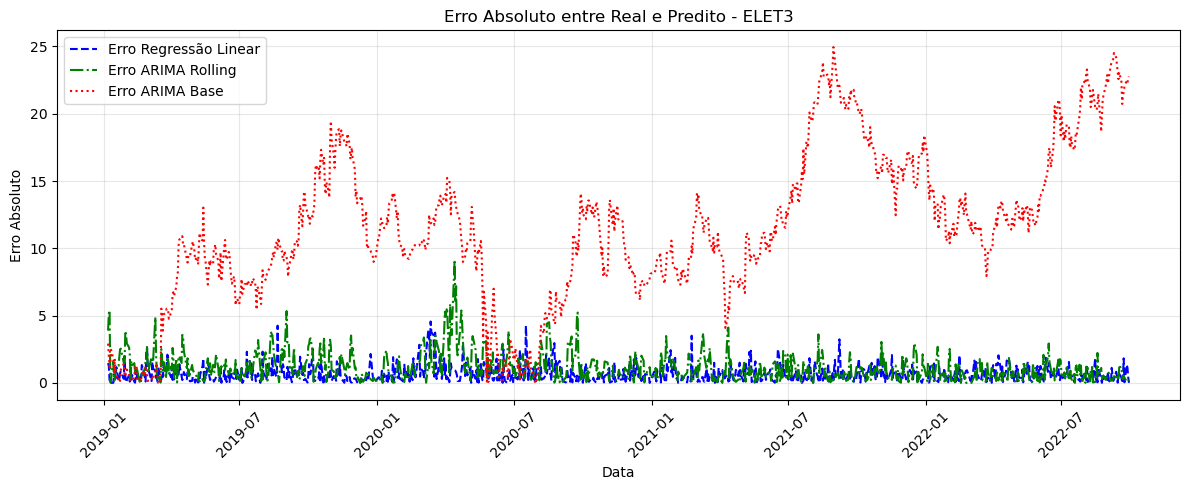

2025-06-16 19:59:32,045 - INFO - Carregando dados do CSV para a ação EQTL3
2025-06-16 19:59:32,062 - INFO - Normalizando dados
2025-06-16 19:59:32,065 - INFO - Treinando modelo usando a equação normal
2025-06-16 19:59:32,066 - INFO - Desnormalizando previsões
2025-06-16 19:59:32,067 - INFO - Avaliando modelo
2025-06-16 19:59:32,071 - INFO - 
Métricas de Treino:
2025-06-16 19:59:32,072 - INFO - MSE: 0.0069
2025-06-16 19:59:32,072 - INFO - RMSE: 0.0832
2025-06-16 19:59:32,073 - INFO - MAE: 0.0535
2025-06-16 19:59:32,074 - INFO - R2: 0.9992
2025-06-16 19:59:32,074 - INFO - 
Métricas de Validação:
2025-06-16 19:59:32,075 - INFO - MSE: 0.0293
2025-06-16 19:59:32,075 - INFO - RMSE: 0.1711
2025-06-16 19:59:32,076 - INFO - MAE: 0.1397
2025-06-16 19:59:32,077 - INFO - R2: 0.9693
2025-06-16 19:59:32,077 - INFO - 
Métricas de Teste:
2025-06-16 19:59:32,078 - INFO - MSE: 0.1571
2025-06-16 19:59:32,079 - INFO - RMSE: 0.3963
2025-06-16 19:59:32,079 - INFO - MAE: 0.2884
2025-06-16 19:59:32,079 - INFO


Processando: EQTL3


2025-06-16 20:02:40,530 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:02:40,531 - INFO - MSE: 0.1489
2025-06-16 20:02:40,531 - INFO - RMSE: 0.3859
2025-06-16 20:02:40,532 - INFO - MAE: 0.2748
2025-06-16 20:02:40,533 - INFO - R2: 0.9853
2025-06-16 20:02:40,598 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 20:02:40,601 - INFO - Carregando dados para EQTL3
2025-06-16 20:02:40,647 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para EQTL3:
MSE: 0.1489
RMSE: 0.3859
MAE: 0.2748
R2: 0.9853


2025-06-16 20:02:41,039 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:02:41,040 - INFO - MSE: 59.8145
2025-06-16 20:02:41,040 - INFO - RMSE: 7.7340
2025-06-16 20:02:41,041 - INFO - MAE: 7.0510
2025-06-16 20:02:41,042 - INFO - R2: -4.9238
2025-06-16 20:02:41,084 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


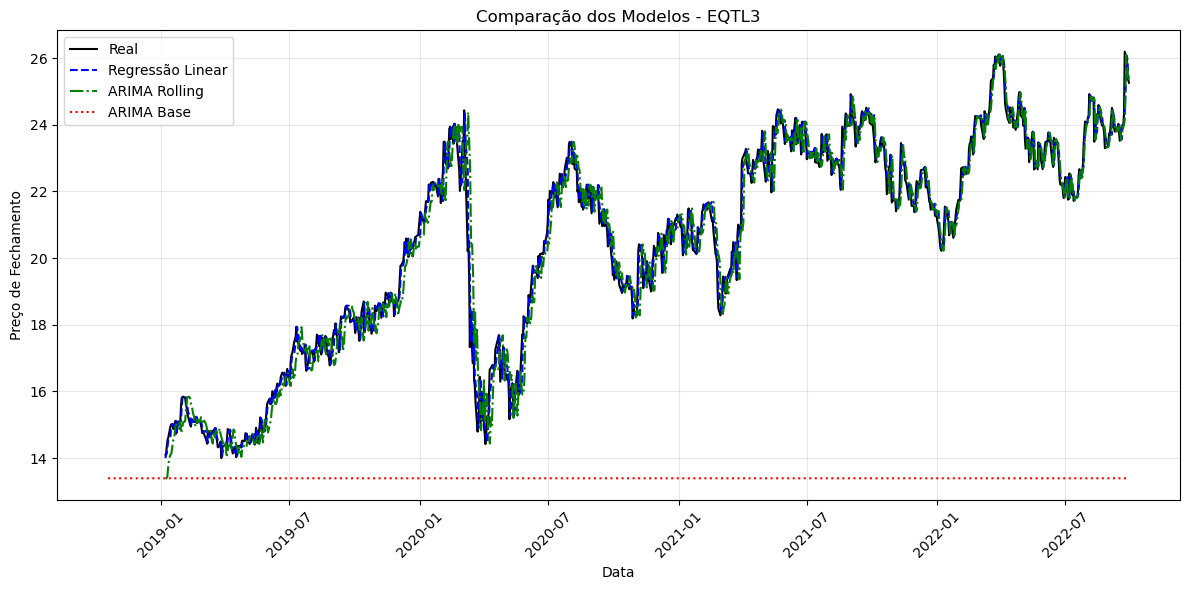

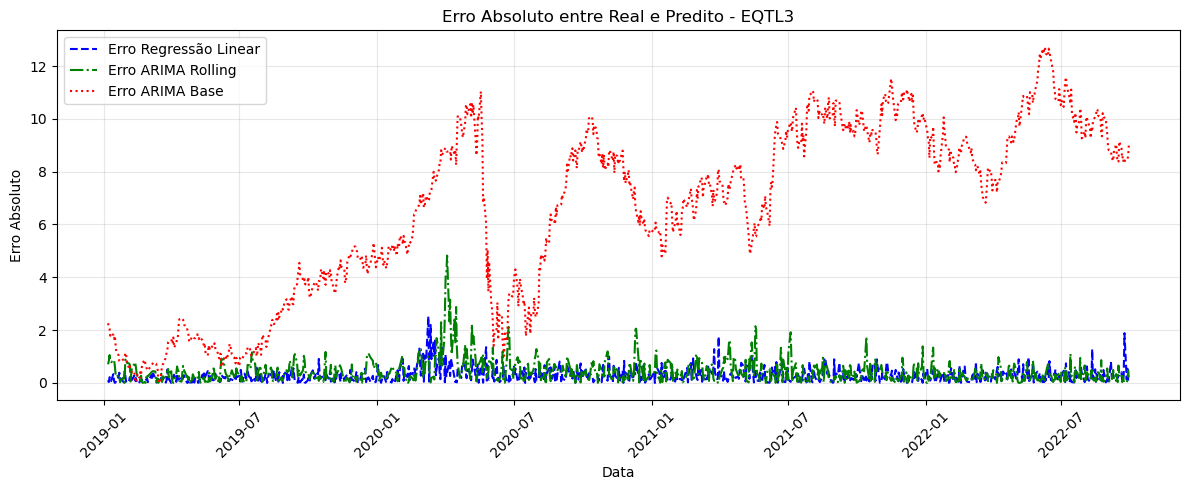

2025-06-16 20:02:41,573 - INFO - Carregando dados do CSV para a ação CMIG4
2025-06-16 20:02:41,598 - INFO - Normalizando dados
2025-06-16 20:02:41,602 - INFO - Treinando modelo usando a equação normal
2025-06-16 20:02:41,605 - INFO - Desnormalizando previsões
2025-06-16 20:02:41,606 - INFO - Avaliando modelo
2025-06-16 20:02:41,614 - INFO - 
Métricas de Treino:
2025-06-16 20:02:41,615 - INFO - MSE: 0.0034
2025-06-16 20:02:41,616 - INFO - RMSE: 0.0584
2025-06-16 20:02:41,617 - INFO - MAE: 0.0404
2025-06-16 20:02:41,618 - INFO - R2: 0.9902
2025-06-16 20:02:41,618 - INFO - 
Métricas de Validação:
2025-06-16 20:02:41,619 - INFO - MSE: 0.0041
2025-06-16 20:02:41,620 - INFO - RMSE: 0.0639
2025-06-16 20:02:41,620 - INFO - MAE: 0.0450
2025-06-16 20:02:41,621 - INFO - R2: 0.9848
2025-06-16 20:02:41,621 - INFO - 
Métricas de Teste:
2025-06-16 20:02:41,622 - INFO - MSE: 0.0093
2025-06-16 20:02:41,622 - INFO - RMSE: 0.0966
2025-06-16 20:02:41,623 - INFO - MAE: 0.0707
2025-06-16 20:02:41,624 - INFO


Processando: CMIG4


2025-06-16 20:05:41,712 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:05:41,714 - INFO - MSE: 0.0088
2025-06-16 20:05:41,715 - INFO - RMSE: 0.0935
2025-06-16 20:05:41,715 - INFO - MAE: 0.0667
2025-06-16 20:05:41,716 - INFO - R2: 0.9913
2025-06-16 20:05:41,776 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 20:05:41,780 - INFO - Carregando dados para CMIG4
2025-06-16 20:05:41,822 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para CMIG4:
MSE: 0.0088
RMSE: 0.0935
MAE: 0.0667
R2: 0.9913


2025-06-16 20:05:42,127 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:05:42,127 - INFO - MSE: 1.3379
2025-06-16 20:05:42,128 - INFO - RMSE: 1.1567
2025-06-16 20:05:42,129 - INFO - MAE: 0.8470
2025-06-16 20:05:42,129 - INFO - R2: -0.3323
2025-06-16 20:05:42,165 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


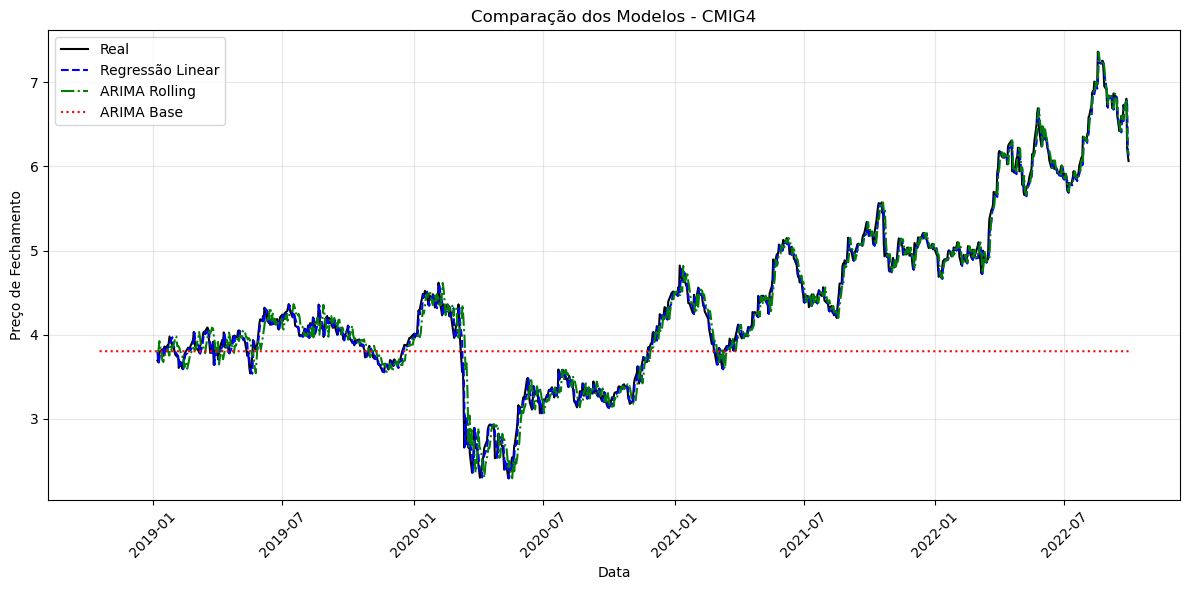

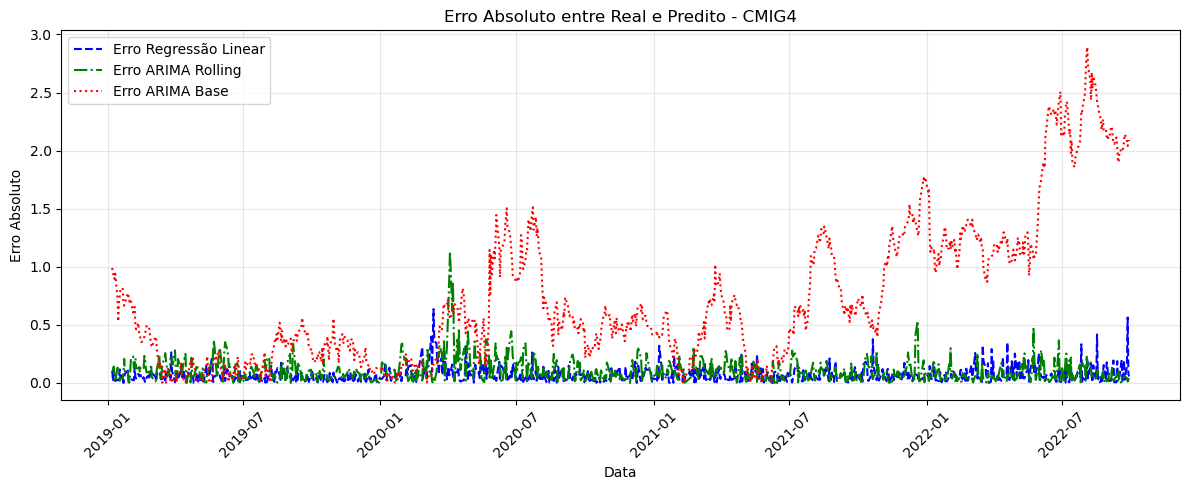

2025-06-16 20:05:42,594 - INFO - Carregando dados do CSV para a ação PETR3
2025-06-16 20:05:42,611 - INFO - Normalizando dados
2025-06-16 20:05:42,614 - INFO - Treinando modelo usando a equação normal
2025-06-16 20:05:42,615 - INFO - Desnormalizando previsões
2025-06-16 20:05:42,616 - INFO - Avaliando modelo
2025-06-16 20:05:42,621 - INFO - 
Métricas de Treino:
2025-06-16 20:05:42,621 - INFO - MSE: 0.0198
2025-06-16 20:05:42,622 - INFO - RMSE: 0.1408
2025-06-16 20:05:42,622 - INFO - MAE: 0.1054
2025-06-16 20:05:42,623 - INFO - R2: 0.9954
2025-06-16 20:05:42,624 - INFO - 
Métricas de Validação:
2025-06-16 20:05:42,624 - INFO - MSE: 0.0547
2025-06-16 20:05:42,625 - INFO - RMSE: 0.2339
2025-06-16 20:05:42,625 - INFO - MAE: 0.1607
2025-06-16 20:05:42,626 - INFO - R2: 0.9542
2025-06-16 20:05:42,627 - INFO - 
Métricas de Teste:
2025-06-16 20:05:42,628 - INFO - MSE: 0.0802
2025-06-16 20:05:42,628 - INFO - RMSE: 0.2832
2025-06-16 20:05:42,629 - INFO - MAE: 0.1916
2025-06-16 20:05:42,629 - INFO


Processando: PETR3


2025-06-16 20:08:40,665 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:08:40,666 - INFO - MSE: 0.0751
2025-06-16 20:08:40,666 - INFO - RMSE: 0.2741
2025-06-16 20:08:40,667 - INFO - MAE: 0.1797
2025-06-16 20:08:40,668 - INFO - R2: 0.9933
2025-06-16 20:08:40,711 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 20:08:40,715 - INFO - Carregando dados para PETR3
2025-06-16 20:08:40,756 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para PETR3:
MSE: 0.0751
RMSE: 0.2741
MAE: 0.1797
R2: 0.9933


2025-06-16 20:08:41,124 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:08:41,125 - INFO - MSE: 16.0281
2025-06-16 20:08:41,125 - INFO - RMSE: 4.0035
2025-06-16 20:08:41,126 - INFO - MAE: 2.7966
2025-06-16 20:08:41,126 - INFO - R2: -0.4271
2025-06-16 20:08:41,161 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


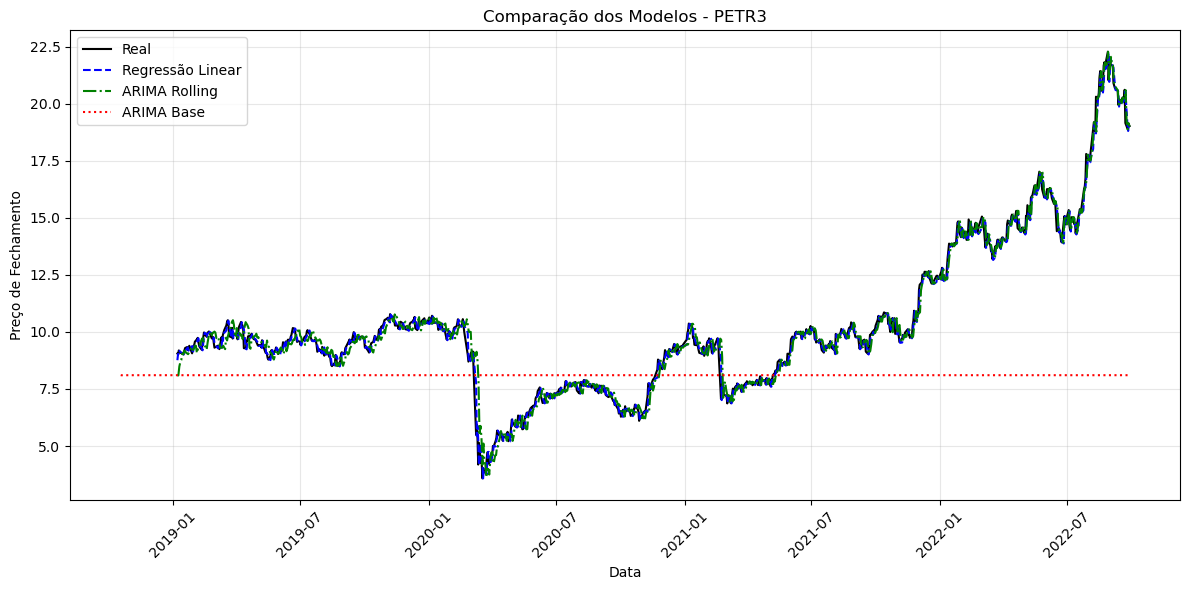

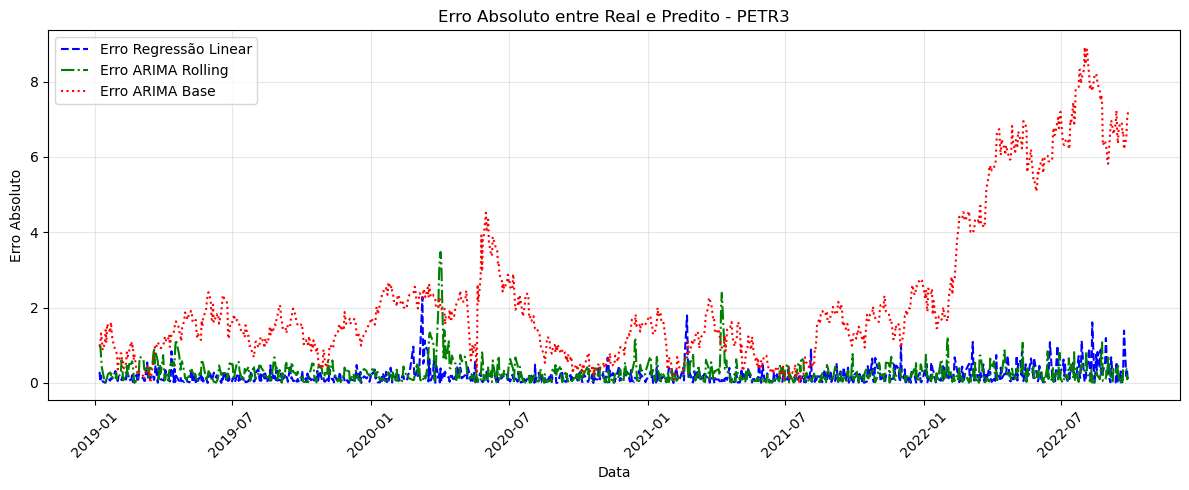

2025-06-16 20:08:41,576 - INFO - Carregando dados do CSV para a ação VALE3
2025-06-16 20:08:41,592 - INFO - Normalizando dados
2025-06-16 20:08:41,594 - INFO - Treinando modelo usando a equação normal
2025-06-16 20:08:41,595 - INFO - Desnormalizando previsões
2025-06-16 20:08:41,596 - INFO - Avaliando modelo
2025-06-16 20:08:41,599 - INFO - 
Métricas de Treino:
2025-06-16 20:08:41,600 - INFO - MSE: 0.1510
2025-06-16 20:08:41,601 - INFO - RMSE: 0.3886
2025-06-16 20:08:41,601 - INFO - MAE: 0.2947
2025-06-16 20:08:41,602 - INFO - R2: 0.9945
2025-06-16 20:08:41,602 - INFO - 
Métricas de Validação:
2025-06-16 20:08:41,604 - INFO - MSE: 0.4229
2025-06-16 20:08:41,604 - INFO - RMSE: 0.6503
2025-06-16 20:08:41,605 - INFO - MAE: 0.5032
2025-06-16 20:08:41,605 - INFO - R2: 0.9682
2025-06-16 20:08:41,606 - INFO - 
Métricas de Teste:
2025-06-16 20:08:41,606 - INFO - MSE: 1.5617
2025-06-16 20:08:41,606 - INFO - RMSE: 1.2497
2025-06-16 20:08:41,608 - INFO - MAE: 0.8785
2025-06-16 20:08:41,608 - INFO


Processando: VALE3


2025-06-16 20:11:41,978 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:11:41,978 - INFO - MSE: 1.4774
2025-06-16 20:11:41,979 - INFO - RMSE: 1.2155
2025-06-16 20:11:41,979 - INFO - MAE: 0.8357
2025-06-16 20:11:41,980 - INFO - R2: 0.9955
2025-06-16 20:11:42,039 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 20:11:42,044 - INFO - Carregando dados para VALE3
2025-06-16 20:11:42,089 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para VALE3:
MSE: 1.4774
RMSE: 1.2155
MAE: 0.8357
R2: 0.9955


2025-06-16 20:11:42,458 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:11:42,459 - INFO - MSE: 640.8722
2025-06-16 20:11:42,459 - INFO - RMSE: 25.3155
2025-06-16 20:11:42,460 - INFO - MAE: 18.8716
2025-06-16 20:11:42,460 - INFO - R2: -0.9444
2025-06-16 20:11:42,510 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


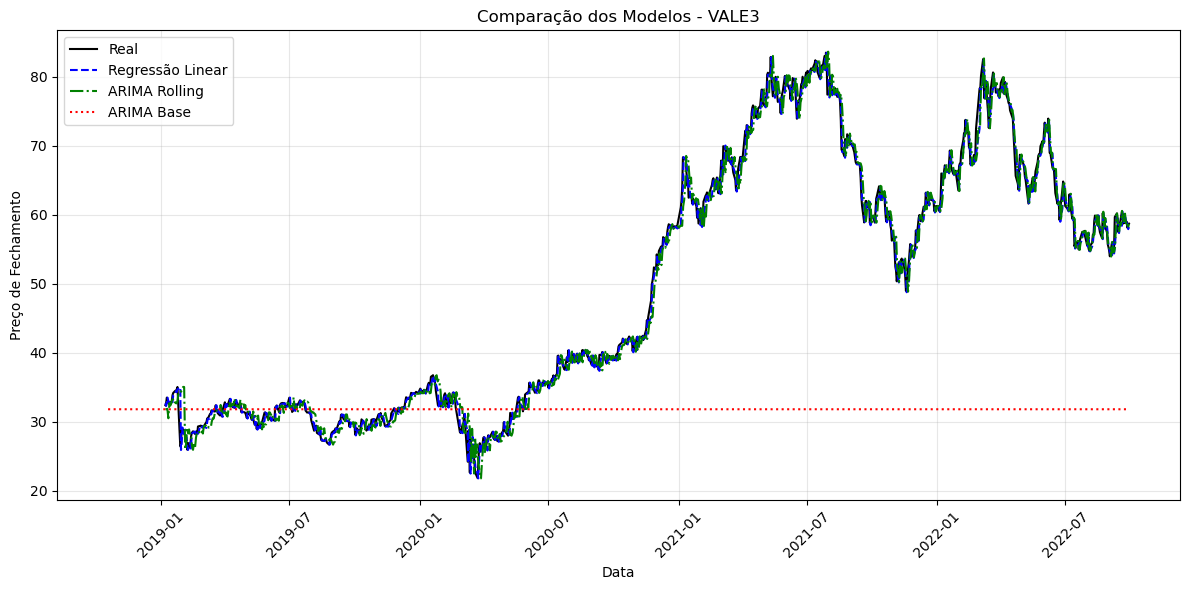

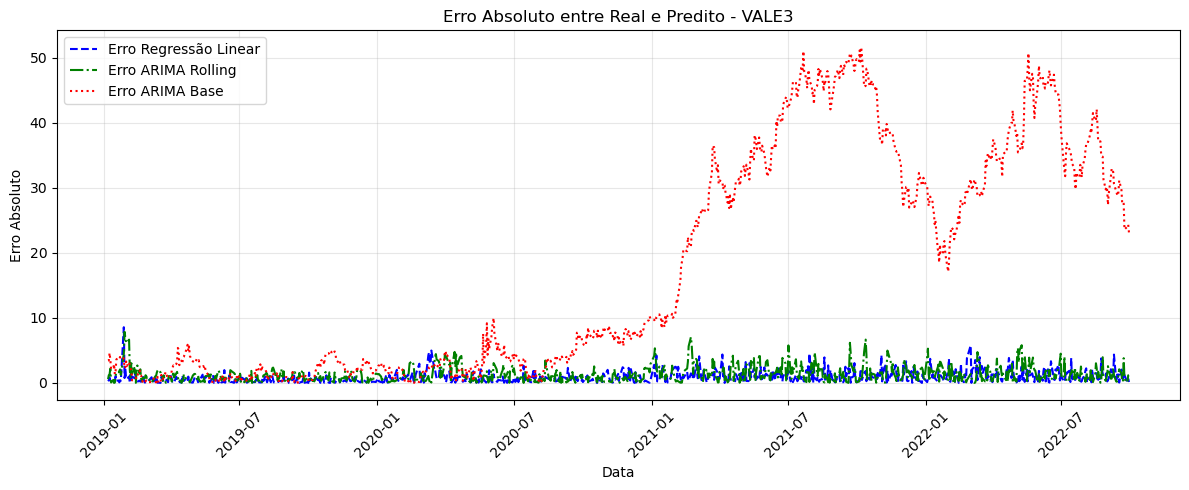

2025-06-16 20:11:42,993 - INFO - Carregando dados do CSV para a ação BRAP3
2025-06-16 20:11:43,022 - INFO - Normalizando dados
2025-06-16 20:11:43,027 - INFO - Treinando modelo usando a equação normal
2025-06-16 20:11:43,030 - INFO - Desnormalizando previsões
2025-06-16 20:11:43,033 - INFO - Avaliando modelo
2025-06-16 20:11:43,039 - INFO - 
Métricas de Treino:
2025-06-16 20:11:43,040 - INFO - MSE: 0.0042
2025-06-16 20:11:43,041 - INFO - RMSE: 0.0644
2025-06-16 20:11:43,042 - INFO - MAE: 0.0461
2025-06-16 20:11:43,042 - INFO - R2: 0.9964
2025-06-16 20:11:43,043 - INFO - 
Métricas de Validação:
2025-06-16 20:11:43,043 - INFO - MSE: 0.0174
2025-06-16 20:11:43,044 - INFO - RMSE: 0.1321
2025-06-16 20:11:43,046 - INFO - MAE: 0.0962
2025-06-16 20:11:43,046 - INFO - R2: 0.8955
2025-06-16 20:11:43,047 - INFO - 
Métricas de Teste:
2025-06-16 20:11:43,048 - INFO - MSE: 0.0829
2025-06-16 20:11:43,048 - INFO - RMSE: 0.2879
2025-06-16 20:11:43,049 - INFO - MAE: 0.2001
2025-06-16 20:11:43,049 - INFO


Processando: BRAP3


2025-06-16 20:14:48,431 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:14:48,432 - INFO - MSE: 0.0787
2025-06-16 20:14:48,432 - INFO - RMSE: 0.2805
2025-06-16 20:14:48,433 - INFO - MAE: 0.1910
2025-06-16 20:14:48,434 - INFO - R2: 0.9968
2025-06-16 20:14:48,490 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/regressao
2025-06-16 20:14:48,494 - INFO - Carregando dados para BRAP3
2025-06-16 20:14:48,552 - INFO - Tamanho do treino: 2346 | Tamanho do teste: 978



Métricas do modelo ARIMA para BRAP3:
MSE: 0.0787
RMSE: 0.2805
MAE: 0.1910
R2: 0.9968


2025-06-16 20:14:49,008 - INFO - 
Métricas no conjunto de teste:
2025-06-16 20:14:49,008 - INFO - MSE: 55.3191
2025-06-16 20:14:49,009 - INFO - RMSE: 7.4377
2025-06-16 20:14:49,010 - INFO - MAE: 5.6334
2025-06-16 20:14:49,011 - INFO - R2: -1.2661
2025-06-16 20:14:49,064 - INFO - Modelo, métricas e previsões salvos em ../../saved_models/arima


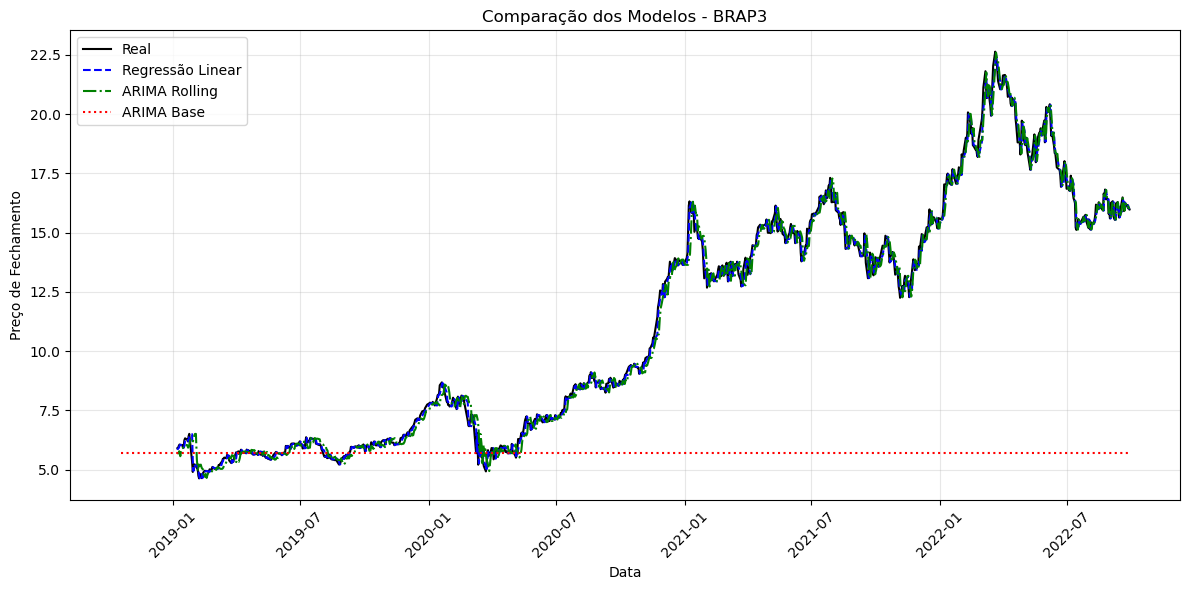

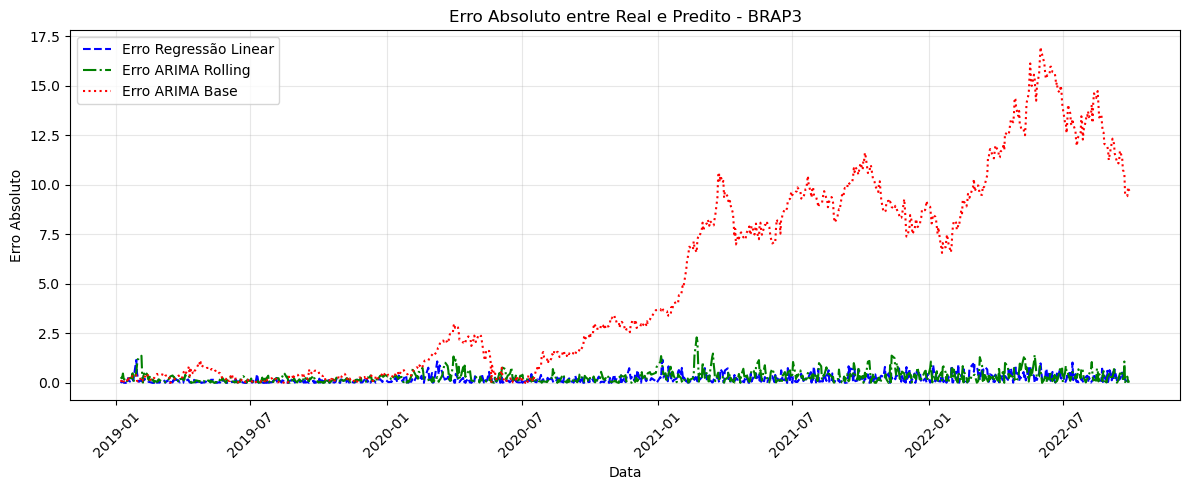

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from main.classes.neural_networks.training.train_linear_regression import train_and_evaluate as train_lr
from main.classes.neural_networks.training.train_arima import train_and_evaluate_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Lista de ações analisadas
acoes = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3' ,'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']

# Configurações
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir_lr = "../../saved_models/regressao"
model_dir_arima = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)
rolling = True  # Se True, usa validação cruzada rolling
split_date="2019-01-01" #data de divisão para treino e teste
step_size = 1 #Tamanho do Rolling Forecast
window = 3

# Carrega DataFrame completo
df = pd.read_csv(csv_path, parse_dates=["Date"])
df.set_index("Date", inplace=True)
df = df.sort_index()

for acao in acoes:
    print(f"\nProcessando: {acao}")
    serie = df[acao].dropna()

    # ---------- Regressão Linear ----------
    _, _, _, _, _, y_test_lr, y_pred_lr = train_lr(csv_path, acao, window, model_dir_lr, version)

    start_idx_lr = df.index.get_indexer([pd.to_datetime(split_date)], method='bfill')[0] + window
    dates_lr = df.index[start_idx_lr : start_idx_lr + len(y_pred_lr)]
    y_test_recalculated_lr = serie.loc[dates_lr]
    # ---------- ARIMA Rolling ----------
    rolling = True
    try:
        arima_model, metrics, predictions = train_and_evaluate_arima(
            csv_path, acao, order, model_dir, version, split_date, rolling, step_size
        )
        
        print(f"\nMétricas do modelo ARIMA para {acao}:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    except Exception as e:
        print(f"Erro durante o treinamento: {e}")
    # Alinhamento correto: previsões no final da série (rolling)
    y_pred_arima_rolling = predictions
    serie_completa = df[acao].dropna()
    # Redefine a escala de tempo do ARIMA Rolling para caber no mesmo intervalo da Regressão Linear
    dates_arima_rolling = pd.date_range(
        start=dates_lr[0],
        end=dates_lr[-1],
        periods=len(y_pred_arima_rolling)
    )

    y_true_arima_rolling = serie_completa.iloc[-len(y_pred_arima_rolling):]
    # Alinhar previsões com as datas corretas
    #start_idx = df.index.get_indexer([pd.to_datetime(split_date)], method='bfill')[0]
    #test_dates = df.index[start_idx : start_idx + len(predictions)]
    #test_values = df[target].iloc[start_idx : start_idx + len(predictions)]
    # ---------- ARIMA Base ----------
    rolling = False
    _, _, y_pred_arima_base = train_and_evaluate_arima(
        csv_path, acao, order, model_dir_arima, version,
        split_date, rolling, step_size
    )
        # Alinha o ARIMA Base com o final da série, assim como o Rolling
    dates_arima_base = serie.index[-len(y_pred_arima_base):]
    y_test_recalculated_base = serie.loc[dates_arima_base]


    # ---------- Plot (ajustado) ----------
    plt.figure(figsize=(12, 6))

    # Plot da série real da regressão linear
    plt.plot(dates_lr, y_test_recalculated_lr, label="Real", color="black")
    plt.plot(dates_lr, y_pred_lr, label="Regressão Linear", linestyle="--", color="blue")

    # Plot da série real e previsão do ARIMA Rolling
    plt.plot(dates_arima_rolling, y_pred_arima_rolling, label="ARIMA Rolling", linestyle="-.", color="green")

    # Plot do ARIMA Base
    plt.plot(dates_arima_base, y_pred_arima_base, label="ARIMA Base", linestyle=":", color="red")

    plt.title(f"Comparação dos Modelos - {acao}")
    plt.xlabel("Data")
    plt.ylabel("Preço de Fechamento")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # 2º plot
    # ---------- Erro absoluto (Real - Predito) ----------

    # Recalcula as datas comprimidas do ARIMA Rolling
    dates_arima_rolling = pd.date_range(
        start=dates_lr[0],
        end=dates_lr[-1],
        periods=len(y_pred_arima_rolling)
    )

    # Interpola os valores reais da série original para bater com as novas datas
    serie_real = df[acao].dropna()
    serie_real_interp = pd.Series(
        np.interp(
            pd.to_numeric(dates_arima_rolling), 
            pd.to_numeric(serie_real.index), 
            serie_real.values
        ),
        index=dates_arima_rolling
    )

    # Calcula erros absolutos
    erro_lr = np.abs(y_test_recalculated_lr - y_pred_lr)
    erro_arima_rolling = np.abs(serie_real_interp.values - y_pred_arima_rolling)
    erro_arima_base = np.abs(y_test_recalculated_base - y_pred_arima_base)

    # Redefine eixo de datas comum
    dates_common = dates_lr[:min(len(erro_lr), len(erro_arima_rolling), len(erro_arima_base))]

    # Truncamento
    erro_lr = erro_lr[:len(dates_common)]
    erro_arima_rolling = erro_arima_rolling[:len(dates_common)]
    erro_arima_base = erro_arima_base[:len(dates_common)]

    # ---------- Plot dos erros absolutos ----------
    plt.figure(figsize=(12, 5))
    plt.plot(dates_common, erro_lr, label="Erro Regressão Linear", linestyle="--", color="blue")
    plt.plot(dates_common, erro_arima_rolling, label="Erro ARIMA Rolling", linestyle="-.", color="green")
    plt.plot(dates_common, erro_arima_base, label="Erro ARIMA Base", linestyle=":", color="red")

    plt.title(f"Erro Absoluto entre Real e Predito - {acao}")
    plt.xlabel("Data")
    plt.ylabel("Erro Absoluto")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
